# Forecasting European day-ahead electricity prices with $t_0$

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/theforecastingcompany/tfc-t0/blob/main/notebooks/03_electricity_day_ahead_prices.ipynb)

> **About other use cases:** $t_0$ is a general-purpose forecasting model from [The Forecasting Company](https://theforecastingcompany.com/). It is not specific to electricity. The same pattern works for any time series with no training. To try it on your own data without code, use [Retrocast](https://app.retrocast.com/).

Europe's day-ahead market sets electricity prices for the next day. Prices vary by hour and by bidding zone. Before the auction closes, a battery operator might want to know which hours will be cheapest. A supplier might care about both the price and its uncertainty.

We use [t0-beta](https://huggingface.co/theforecastingcompany/t0-beta) to forecast 24 hourly prices in four zones: France, Germany and Luxembourg, Belgium, and the Netherlands. The model is used without training on these data. We compare forecasts with and without information about expected demand, renewable generation, holidays and weather.

We first make a forecast for one day, then test it across September 2025. Alongside price error, we measure whether the forecast identifies the cheapest hours. This matters when the *order* of prices is more useful than their exact values.

Price and grid forecast data come from the [Energy-Charts API](https://api.energy-charts.info) by Fraunhofer ISE (source: Bundesnetzagentur | SMARD.de, ENTSO-E), licensed [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). Weather forecasts come from [Open-Meteo](https://open-meteo.com) (CC BY 4.0). Neither API needs a key.

## Setup

On Colab, select a GPU runtime under *Runtime → Change runtime type*. You can also run the model on a CPU or Apple silicon (MPS).

In [ ]:
%pip install -q "tfc-t0>=0.5.0" holidays requests scipy tqdm matplotlib pandas pyarrow

In [ ]:
import pathlib
import time

import holidays
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
from scipy.stats import kendalltau, spearmanr
from tqdm.auto import tqdm

from t0 import T0Forecaster

# Plot styling options
from t0.utils.style import (
    COLOR_CONTEXT,
    COLOR_FCD_LINE,
    COLOR_FORECAST,
    COLOR_TARGET,
    PREDICTION_INTERVAL_ALPHA,
    use_t0_style,
)

use_t0_style()

Use a GPU if one is available. Otherwise, use MPS on Apple silicon or a CPU.

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: mps


In [ ]:
ZONES = ["FR", "DE-LU", "BE", "NL"]  # Energy-Charts bidding-zone codes
COUNTRIES = ["fr", "de", "be", "nl"]  # matching country codes for grid forecasts
START, END = "2023-01-01", "2025-12-31"  # 2023 is only context: we evaluate on 2024-2025
CACHE = pathlib.Path("data")
CACHE.mkdir(exist_ok=True)

## 1. Data

### Prices and grid forecasts (Energy-Charts)

We fetch prices for each bidding zone and forecasts of electricity demand (load), solar generation and wind generation. Transmission system operators (TSOs) publish these forecasts for the day-ahead market. The archive does not establish that every solar and wind forecast was available before the auction. We return to this limitation when interpreting the results. From October 2025, the market trades in 15 minute intervals. We average those prices by hour so the series have the same frequency.

The API returns one series per request. The 20 **requests download about 20 MB and can take a few minutes**. If Energy-Charts limits the request rate, the progress bar counts down before retrying. We cache the data under `data/` so later runs do not need another download.

In [ ]:
def energy_charts(path: str, bar, **params) -> dict:
    # GET an Energy-Charts endpoint; on HTTP 429, count down on the progress bar and retry.
    for attempt in range(8):
        r = requests.get(f"https://api.energy-charts.info/{path}", params=params, timeout=300)
        if r.status_code != 429:
            r.raise_for_status()
            time.sleep(1)  # be gentle with the API between requests
            return r.json()
        for remaining in range(10 * (attempt + 1), 0, -1):
            bar.set_postfix_str(f"rate-limited, retrying in {remaining}s")
            time.sleep(1)
    raise RuntimeError(f"Energy-Charts kept rate-limiting {path} {params}")


def to_hourly(unix_seconds, values) -> pd.Series:
    s = pd.Series(values, index=pd.to_datetime(unix_seconds, unit="s", utc=True), dtype="float64")
    return s.resample("1h").mean()


# (column name, endpoint, query parameters, key holding the values)
REQUESTS = [(f"price_{z}", "price", {"bzn": z}, "price") for z in ZONES] + [
    (
        f"fcst_{kind}_{c}",
        "public_power_forecast",
        {"country": c, "production_type": kind, "forecast_type": "day-ahead"},
        "forecast_values",
    )
    for c in COUNTRIES
    for kind in ["load", "solar", "wind_onshore", "wind_offshore"]
]

grid_file = CACHE / "energy_charts.parquet"
if grid_file.exists():
    grid = pd.read_parquet(grid_file)
else:
    cols = {}
    with tqdm(REQUESTS, desc="Energy-Charts", unit="series") as bar:
        for name, path, params, key in bar:
            bar.set_postfix_str(name)
            d = energy_charts(path, bar, start=START, end=END, **params)
            cols[name] = to_hourly(d["unix_seconds"], d[key])
    grid = pd.DataFrame(cols).interpolate(limit=6)  # a handful of isolated gaps
    grid.to_parquet(grid_file)
print(grid.shape, grid.index.min(), "->", grid.index.max())
grid.filter(like="price_").describe().round(1)

(26304, 20) 2022-12-31 23:00:00+00:00 -> 2025-12-31 22:00:00+00:00


,price_FR,price_DE-LU,price_BE,price_NL
count,26304.0,26304.0,26304.0,26304.0
mean,72.0,87.7,83.4,86.6
std,47.6,51.3,46.9,50.0
min,-134.9,-500.0,-462.3,-500.0
25%,34.1,65.1,59.2,65.7
50%,74.7,90.1,86.2,90.0
75%,103.2,113.0,110.0,112.1
max,473.3,936.3,565.5,873.0


### Weather forecasts that existed before the auction (Open-Meteo)

A backtest must use only information available when the forecast is made. We forecast delivery day D on the morning of D minus 1, before the auction. The temperature actually observed on D would not be available then. We instead use Open-Meteo's [previous-runs API](https://open-meteo.com/en/docs/previous-runs-api). Its `*_previous_day2` fields contain weather forecasts issued two days before delivery.

For each country, we average temperature, wind speed at 100 m and solar radiation across two or three locations. This forecast archive is complete from mid February 2024. Earlier hours remain `NaN`. The model treats these values as missing, not as zero.

In [ ]:
POINTS = {  # a few load / generation centres per country
    "fr": [(48.86, 2.35), (45.76, 4.84), (47.22, -1.55)],  # Paris, Lyon, Nantes
    "de": [(53.55, 10.00), (50.11, 8.68), (48.14, 11.58)],  # Hamburg, Frankfurt, Munich
    "be": [(50.85, 4.35), (51.23, 2.92)],  # Brussels, Ostend
    "nl": [(52.37, 4.90), (51.92, 4.48)],  # Amsterdam, Rotterdam
}
WX_VARS = {
    "temperature_2m_previous_day2": "temp",
    "wind_speed_100m_previous_day2": "wind100",
    "shortwave_radiation_previous_day2": "solar_rad",
}

wx_file = CACHE / "weather.parquet"
if wx_file.exists():
    weather = pd.read_parquet(wx_file)
else:
    cols = {}
    for c, pts in tqdm(POINTS.items(), desc="Open-Meteo", unit="country"):
        r = requests.get(
            "https://previous-runs-api.open-meteo.com/v1/forecast",
            timeout=300,
            params=dict(
                latitude=",".join(str(p[0]) for p in pts),
                longitude=",".join(str(p[1]) for p in pts),
                start_date=START,
                end_date=END,
                hourly=",".join(WX_VARS),
                timezone="UTC",
            ),
        )
        r.raise_for_status()
        sites = r.json() if isinstance(r.json(), list) else [r.json()]
        mean = sum(pd.DataFrame(s["hourly"]).set_index("time").astype(float) for s in sites) / len(sites)
        mean.index = pd.to_datetime(mean.index, utc=True)
        for var, short in WX_VARS.items():
            cols[f"wx_{short}_{c}"] = mean[var]
    weather = pd.DataFrame(cols)
    weather.to_parquet(wx_file)

df = grid.join(weather)
print(f"weather available: {weather.notna().all(axis=1).idxmax():%Y-%m-%d} onwards")

weather available: 2024-02-17 onwards


### Covariates

Covariates are inputs other than past prices. The model can handle both past and future-known covariates. We try four sets of covariates:

| Set | Input | Series |
|---|---|---|
| `load` | TSO forecast of electricity demand in each country | 4 |
| `residual_load` | Forecast demand minus forecast solar and wind generation in each country. This approximates demand that other generators must meet. | 4 |
| `holidays` | Public holiday indicator for each country | 4 |
| `weather` | Forecast temperature, wind and solar radiation in each country | 12 |

In [ ]:
local = df.index.tz_convert("Europe/Brussels")
prices = df[[f"price_{z}" for z in ZONES]].to_numpy(np.float32).T  # [4, T]

load = df[[f"fcst_load_{c}" for c in COUNTRIES]].to_numpy(np.float32).T
renewables = np.stack(
    [df[f"fcst_solar_{c}"] + df[f"fcst_wind_onshore_{c}"] + df[f"fcst_wind_offshore_{c}"] for c in COUNTRIES]
).astype(np.float32)
local_dates = pd.Series(local.date)
calendars = [holidays.country_holidays(c.upper(), years=range(2022, 2027)) for c in COUNTRIES]
holiday_flags = np.stack([local_dates.map(lambda d, cal=cal: float(d in cal)) for cal in calendars]).astype(np.float32)
weather_rows = df[[c for c in df.columns if c.startswith("wx_")]].to_numpy(np.float32).T  # NaN = missing

COVARIATES = {"load": load, "residual_load": load - renewables, "holidays": holiday_flags, "weather": weather_rows}
{k: v.shape for k, v in COVARIATES.items()}

{'load': (4, 26304),
 'residual_load': (4, 26304),
 'holidays': (4, 26304),
 'weather': (12, 26304)}

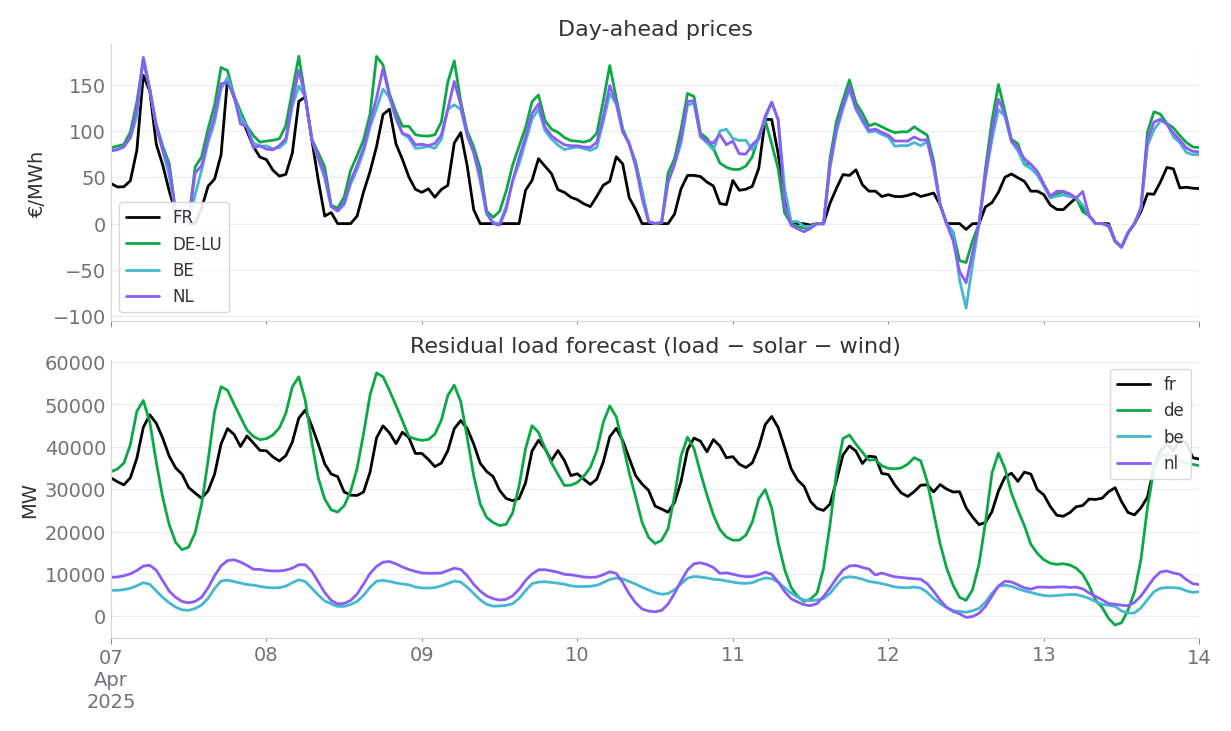

In [ ]:
week = slice(pd.Timestamp("2025-04-07", tz="UTC"), pd.Timestamp("2025-04-14", tz="UTC"))
zone_colors = [COLOR_TARGET, COLOR_FORECAST, "#45B7D1", "#8b5cf6"]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True, layout="constrained")
df.loc[week, [f"price_{z}" for z in ZONES]].set_axis(ZONES, axis=1).plot(ax=a1, color=zone_colors)
a1.set_ylabel("€/MWh")
a1.set_title("Day-ahead prices")
pd.DataFrame((load - renewables).T, index=df.index, columns=COUNTRIES).loc[week].plot(ax=a2, color=zone_colors)
a2.set_ylabel("MW")
a2.set_title("Residual load forecast (load − solar − wind)")
plt.show()

## 2. The forecasting setup

Each forecast starts at local midnight on delivery day D. At that point we use the prices published up to D minus 1. Those prices are known before the auction for D.

- **History:** up to 8,192 hours of prices, about 11 months. This is the longest context t0 accepts.
- **Forecast:** the next 24 hourly prices, starting at local midnight. On the two days when clocks change, 24 hours do not match one full local calendar day. We keep the 24 hour horizon for this example.
- **Targets:** prices for four zones in one model call. The model can use patterns shared across zones.
- **Other inputs:** the covariates go into `future_covariates`, with shape `[batch, n_covariates, context + horizon]`.

In [ ]:
CONTEXT = 8192
HORIZON = 24
QUANTILES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
MEDIAN = QUANTILES.index(0.5)

model = T0Forecaster.from_pretrained("theforecastingcompany/t0-beta").to(DEVICE).eval()
print(f"{sum(p.numel() for p in model.parameters()) / 1e6:.0f}M parameters")

# Forecast origins: local midnight of every day in 2024-2025 with a full context behind it.
t_index = np.arange(len(df))
origins = np.where((local.hour == 0) & (t_index >= CONTEXT) & (local.year >= 2024) & (t_index + HORIZON <= len(df)))[0]
print(f"{len(origins)} daily origins, {local[origins[0]]:%Y-%m-%d} .. {local[origins[-1]]:%Y-%m-%d}")


def forecast(origin_idx, covariate_sets=(), batch_size=16, progress=None):
    # Joint 24h forecast of the four zones for each origin -> [n_origins, 4, 24, n_quantiles].
    ctx = np.stack([prices[:, o - CONTEXT : o] for o in origin_idx])
    cov = None
    if covariate_sets:
        cov = np.concatenate(
            [np.stack([COVARIATES[k][:, o - CONTEXT : o + HORIZON] for o in origin_idx]) for k in covariate_sets],
            axis=1,
        )
    out = []
    for i in range(0, len(ctx), batch_size):
        kw = {} if cov is None else {"future_covariates": cov[i : i + batch_size]}
        out.append(
            model.predict(ctx[i : i + batch_size], horizon=HORIZON, quantile_levels=QUANTILES, **kw)
            .quantiles.float()
            .cpu()
            .numpy()
        )
        if progress is not None:
            progress.update(len(ctx[i : i + batch_size]))
    return np.concatenate(out)

256M parameters
731 daily origins, 2024-01-01 .. 2025-12-31


## 3. One forecast

We start with 10 April 2025. For each zone, we compare the observed prices with two forecasts. One uses only past prices. The other also uses the forecast of residual load. The shaded areas cover the model's 10th to 90th percentile forecasts.

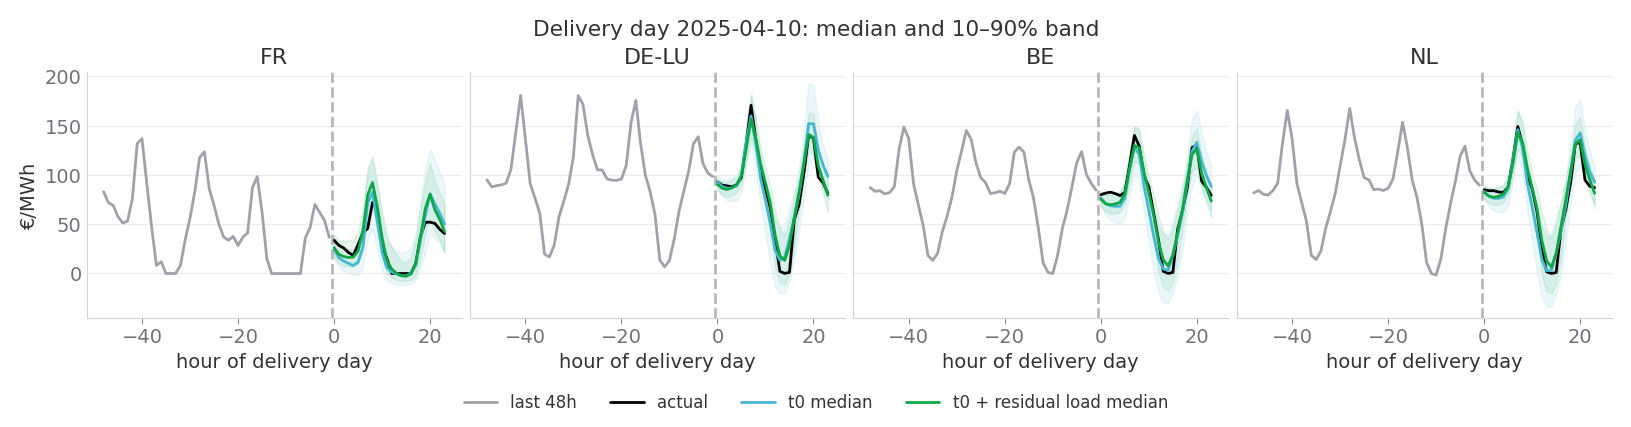

In [ ]:
day = np.where(local[origins].strftime("%Y-%m-%d") == "2025-04-10")[0][0]
o = origins[day]
q_plain, q_resload = forecast([o])[0], forecast([o], ["residual_load"])[0]
truth_day = prices[:, o : o + HORIZON]
hours = np.arange(HORIZON)

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True, layout="constrained")
for z, ax in enumerate(axes):
    ax.plot(np.arange(-48, 0), prices[z, o - 48 : o], color=COLOR_CONTEXT, label="last 48h")
    ax.plot(hours, truth_day[z], color=COLOR_TARGET, label="actual")
    for q, colour, label in [(q_plain, "#45B7D1", "t0"), (q_resload, COLOR_FORECAST, "t0 + residual load")]:
        ax.fill_between(hours, q[z, :, 0], q[z, :, -1], color=colour, alpha=PREDICTION_INTERVAL_ALPHA)
        ax.plot(hours, q[z, :, MEDIAN], color=colour, label=f"{label} median")
    ax.axvline(-0.5, color=COLOR_FCD_LINE, alpha=0.5, ls="--")
    ax.set_title(ZONES[z])
    ax.set_xlabel("hour of delivery day")
axes[0].set_ylabel("€/MWh")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncol=4, frameon=False)
fig.suptitle(f"Delivery day {local[o]:%Y-%m-%d}: median and 10–90% band")
plt.show()

## 4. Rolling backtest

We now make one forecast per day for each set of covariates. We compare them with two simple baselines: the price at the same hour yesterday and the price at the same hour last week. We measure:

- **MAE (€/MWh):** the average absolute error of the median forecast. Lower is better.
- **WQL:** weighted quantile loss across the nine forecast quantiles. It measures both accuracy and uncertainty. Lower is better.
- **80% coverage:** the share of observed prices inside the forecast's 10th to 90th percentile range. A calibrated range should contain about 80% of observations.

By default we test the 30 delivery days in September 2025. Expect roughly 2 to 5 minutes for the seven model runs on a single GPU, plus model loading and data downloads on the first run. CPU runs take longer. To run the full year, change the date range in the next cell to 1 January through 31 December 2025. The full year takes about 25 minutes on a single GPU. Times depend on your hardware. Some early 2025 contexts include missing weather values from before the forecast archive begins.

In [ ]:
# Default: September 2025. The end date is excluded.
# For the full 2025 backtest, use 2025-01-01 and 2026-01-01 instead.
BACKTEST_START = pd.Timestamp("2025-09-01", tz="Europe/Brussels")
BACKTEST_END = pd.Timestamp("2025-10-01", tz="Europe/Brussels")
ORIGINS = origins[(local[origins] >= BACKTEST_START) & (local[origins] < BACKTEST_END)]
print(f"Backtesting {len(ORIGINS)} days, {local[ORIGINS[0]]:%Y-%m-%d} to {local[ORIGINS[-1]]:%Y-%m-%d}")
ARMS = {
    "t0 (no covariates)": [],
    "+ holidays": ["holidays"],
    "+ load": ["load"],
    "+ weather": ["weather"],
    "+ load + weather": ["load", "weather"],
    "+ residual load": ["residual_load"],
    "+ residual load + holidays": ["residual_load", "holidays"],
}
results = {}
with tqdm(total=len(ORIGINS) * len(ARMS), desc="Backtest", unit="forecast") as bar:
    for name, sets in ARMS.items():
        bar.set_postfix_str(name)
        t = time.time()
        results[name] = forecast(ORIGINS, sets, progress=bar)
        tqdm.write(f"{name:40s} {time.time() - t:5.0f}s")

truth = np.stack([prices[:, o : o + HORIZON] for o in ORIGINS])


def repeat(point):
    # A point forecast as degenerate quantiles, so baselines go through the same metrics.
    return np.repeat(point[..., None], len(QUANTILES), axis=-1)


results["naive: same hour yesterday"] = repeat(np.stack([prices[:, o - 24 : o] for o in ORIGINS]))
results["naive: same hour last week"] = repeat(np.stack([prices[:, o - 168 : o - 144] for o in ORIGINS]))

Backtesting 30 days, 2025-09-01 to 2025-09-30


Backtest:  14%|███████▌                                             | 30/210 [00:05<00:30,  5.98forecast/s, + holidays]

t0 (no covariates)                           5s


Backtest:  29%|████████████████▎                                        | 60/210 [00:15<00:42,  3.54forecast/s, + load]

+ holidays                                  10s


...

+ load + weather                            27s


Backtest:  86%|██████████████████████████████▊     | 180/210 [01:22<00:15,  1.91forecast/s, + residual load + holidays]

+ residual load                             10s


Backtest: 100%|████████████████████████████████████| 210/210 [01:38<00:00,  2.13forecast/s, + residual load + holidays]

+ residual load + holidays                  16s


### Price accuracy

The table reports each metric across all four zones. It also shows MAE for each zone separately. The simple baselines produce only one price per hour, so they have no meaningful uncertainty coverage.

In [ ]:
def wql(q, y):
    loss = sum(np.maximum(a * (y - q[..., i]), (a - 1) * (y - q[..., i])) for i, a in enumerate(QUANTILES))
    return (2 * loss / len(QUANTILES)).sum() / np.abs(y).sum()


def accuracy(results, truth, mask=slice(None)):
    rows = {}
    for name, q in results.items():
        q, y = q[mask], truth[mask]
        med = q[..., MEDIAN]
        rows[name] = {
            "MAE": np.abs(med - y).mean(),
            "WQL": wql(q, y),
            "80% coverage": np.nan if name.startswith("naive") else ((y >= q[..., 0]) & (y <= q[..., -1])).mean(),
            **{f"MAE {z}": np.abs(med[:, i] - y[:, i]).mean() for i, z in enumerate(ZONES)},
        }
    return pd.DataFrame(rows).T


accuracy(results, truth).round(3)

,MAE,WQL,80% coverage,MAE FR,MAE DE-LU,MAE BE,MAE NL
t0 (no covariates),17.771,0.214,0.809,15.239,20.984,16.017,18.843
+ holidays,17.670,0.213,0.808,14.478,21.531,15.718,18.952
+ load,17.213,0.209,0.790,14.375,20.572,15.449,18.456
+ weather,14.890,0.178,0.812,12.767,17.944,12.972,15.876
+ load + weather,15.003,0.178,0.810,13.738,17.266,13.065,15.941
+ residual load,11.581,0.138,0.828,12.275,11.886,10.836,11.327
+ residual load + holidays,11.233,0.133,0.817,11.917,11.313,10.636,11.064
naive: same hour yesterday,28.422,0.433,NaN,21.091,33.411,28.305,30.881
naive: same hour last week,36.461,0.555,NaN,31.134,41.104,35.845,37.761


## 5. Does the forecast order the hours correctly?

A battery operator may care more about when to charge than about the exact price. A forecast can miss the price level but still identify the cheapest hours. We compare the order of the 24 forecast prices with the order of the observed prices for each zone and day.

- **Spearman ρ and Kendall τ:** two measures of rank correlation. A value of 1 means the orders match.
- **Pairwise order accuracy:** the share of pairs of hours placed in the right order. There are 276 pairs in a 24 hour day.
- **Cheapest four and priciest four:** the share of the four selected hours that also appear among the observed cheapest or priciest four.
- **Minimum and maximum hour within one hour:** whether the forecast places the lowest or highest price within an hour of the observed one.

In [ ]:
def ordering(forecast_median, actual):
    # Mean ordering metrics over all zone-days; inputs [days, zones, 24].
    pairs = np.triu_indices(HORIZON, 1)
    rows = []
    for f, a in zip(forecast_median.reshape(-1, HORIZON), actual.reshape(-1, HORIZON), strict=True):
        df_, da = f[pairs[0]] - f[pairs[1]], a[pairs[0]] - a[pairs[1]]
        ties = da == 0
        rows.append(
            {
                "Spearman ρ": spearmanr(f, a).statistic,
                "Kendall τ": kendalltau(f, a).statistic,
                "pairwise order accuracy": np.mean(np.sign(df_[~ties]) == np.sign(da[~ties])),
                "cheapest-4 hit": len(set(np.argsort(f)[:4]) & set(np.argsort(a)[:4])) / 4,
                "priciest-4 hit": len(set(np.argsort(f)[-4:]) & set(np.argsort(a)[-4:])) / 4,
                "min hour ±1h": abs(int(np.argmin(f)) - int(np.argmin(a))) <= 1,
                "max hour ±1h": abs(int(np.argmax(f)) - int(np.argmax(a))) <= 1,
            }
        )
    return pd.DataFrame(rows).mean()


order_table = pd.DataFrame({name: ordering(q[..., MEDIAN], truth) for name, q in results.items()}).T
order_table.round(3)

,Spearman ρ,Kendall τ,pairwise order accuracy,cheapest-4 hit,priciest-4 hit,min hour ±1h,max hour ±1h
t0 (no covariates),0.876,0.751,0.877,0.754,0.771,0.825,0.783
+ holidays,0.877,0.751,0.877,0.754,0.775,0.817,0.792
+ load,0.876,0.751,0.876,0.762,0.779,0.833,0.783
+ weather,0.896,0.772,0.887,0.765,0.796,0.833,0.800
+ load + weather,0.895,0.772,0.887,0.769,0.798,0.850,0.783
+ residual load,0.919,0.807,0.905,0.802,0.804,0.883,0.808
+ residual load + holidays,0.923,0.813,0.908,0.802,0.815,0.858,0.833
naive: same hour yesterday,0.794,0.647,0.821,0.715,0.673,0.725,0.725
naive: same hour last week,0.792,0.649,0.822,0.704,0.656,0.742,0.683


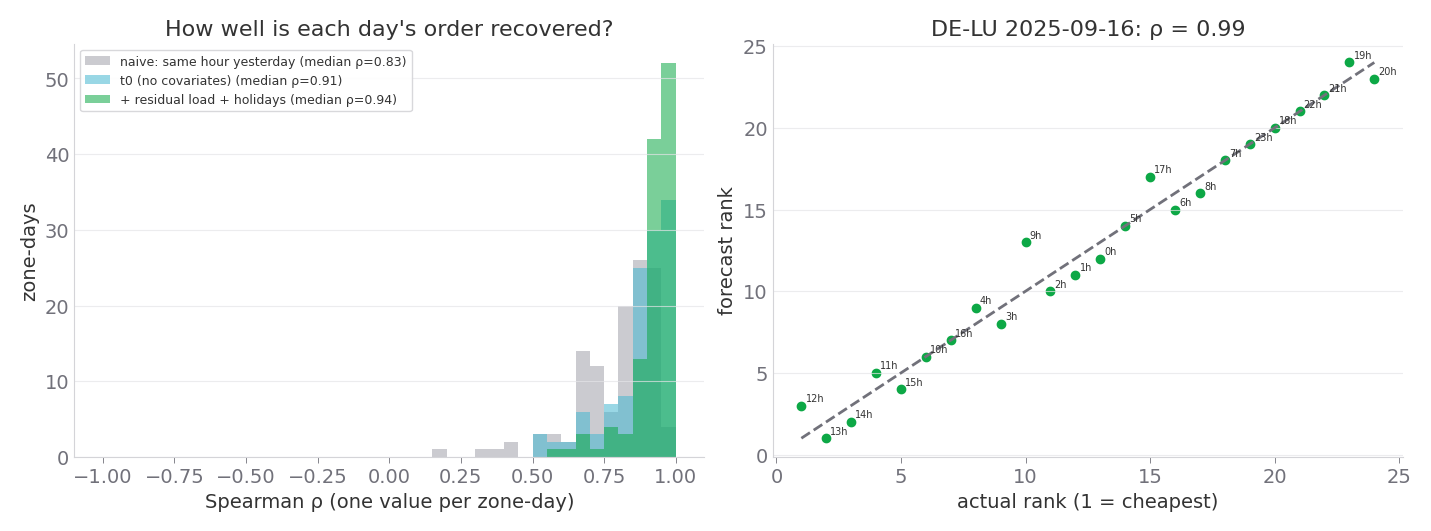

In [ ]:
best = "+ residual load + holidays"


def rho(name):
    # Spearman correlation between forecast and actual hourly order, one value per zone-day.
    pairs = zip(results[name][..., MEDIAN].reshape(-1, HORIZON), truth.reshape(-1, HORIZON), strict=True)
    return np.array([spearmanr(f, a).statistic for f, a in pairs])


fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5), layout="constrained")
bins = np.linspace(-1, 1, 41)
for name, colour in [
    ("naive: same hour yesterday", COLOR_CONTEXT),
    ("t0 (no covariates)", "#45B7D1"),
    (best, COLOR_FORECAST),
]:
    values = rho(name)
    a1.hist(values, bins=bins, alpha=0.55, color=colour, label=f"{name} (median ρ={np.nanmedian(values):.2f})")
a1.set_xlabel("Spearman ρ (one value per zone-day)")
a1.set_ylabel("zone-days")
a1.legend(fontsize=9)
a1.set_title("How well is each day's order recovered?")

# One day: forecast rank vs actual rank for each hour
z = ZONES.index("DE-LU")
k = int(np.where(ORIGINS == o)[0][0]) if o in ORIGINS else len(ORIGINS) // 2  # use a September day by default
o_k = ORIGINS[k]
f, a = results[best][k, z, :, MEDIAN], truth[k, z]
fr, ar = f.argsort().argsort() + 1, a.argsort().argsort() + 1
a2.scatter(ar, fr, color=COLOR_FORECAST)
for h in range(HORIZON):
    a2.annotate(f"{h}h", (ar[h], fr[h]), fontsize=7, xytext=(3, 3), textcoords="offset points")
a2.plot([1, 24], [1, 24], color=COLOR_FCD_LINE, ls="--")
a2.set_xlabel("actual rank (1 = cheapest)")
a2.set_ylabel("forecast rank")
a2.set_title(f"DE-LU {local[o_k]:%Y-%m-%d}: ρ = {spearmanr(f, a).statistic:.2f}")
plt.show()

## 6. What we found

The table below is from a full year run in 2025, not the September backtest above. It uses t0-beta with an 8,192 hour context for four zones. Your results may vary slightly on other hardware. For results from the selected month, use the metric tables above.

| Input | MAE €/MWh | WQL | 80% coverage | Spearman ρ | Cheapest four hit | Lowest hour within 1h |
|---|---|---|---|---|---|---|
| Same hour yesterday | 23.1 | 0.284 | N/A | 0.78 | 67% | 64% |
| t0, past prices only | 15.7 | 0.153 | 81% | 0.88 | 75% | 76% |
| + holidays | 15.6 | 0.153 | 81% | 0.88 | 75% | 75% |
| + load forecast | 15.2 | 0.148 | 80% | 0.88 | 75% | 75% |
| + weather forecast | 13.7 | 0.134 | 78% | 0.90 | 77% | 78% |
| + load + weather | 13.6 | 0.133 | 78% | 0.90 | 76% | 78% |
| + residual load | 10.9 | 0.106 | 82% | 0.92 | 80% | 82% |
| **+ residual load + holidays** | **10.7** | **0.104** | 81% | **0.93** | **80%** | 81% |

With past prices alone, t0 has an MAE of 15.7 €/MWh, compared with 23.1 for the same hour yesterday. Its 10th to 90th percentile range contains 81% of observed prices, close to the expected 80%.

Adding the residual load forecast reduces MAE to 10.9 €/MWh. Adding holidays brings it to 10.7. Weather forecasts also help, though less than residual load in this run. The TSO solar and wind forecasts used in residual load may not always have been published before the auction. That result should not be treated as a strictly pre-auction backtest. The weather inputs come from forecasts issued before the auction.

Ranking improves too. With past prices alone, the average Spearman correlation is 0.88. With residual load and holidays it is 0.93. The four cheapest forecast hours include, on average, 80% of the four cheapest observed hours.

## Next steps

- **Forecast your own data:** [Retrocast](https://app.retrocast.com/) runs $t_0$ on data you upload. You can backtest it and compare it with other open-weight models and sets of covariates, without writing code.
- **Run at scale:** the hosted API gives faster inference with no local weights. See the [Retrocast documentation](https://docs.retrocast.com/).
- **More notebooks:** the [inference quickstart](https://github.com/theforecastingcompany/tfc-t0/blob/main/notebooks/01_inference_quickstart.ipynb) and [LoRA fine-tuning](https://github.com/theforecastingcompany/tfc-t0/blob/main/notebooks/02_finetune_lora.ipynb) notebooks cover other ways to use the model.

$t_0$ is built by [The Forecasting Company](https://theforecastingcompany.com/).